In [20]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.api as sm
from ISLP import confusion_table
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA,
                                           QuadraticDiscriminantAnalysis as QDA)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

14. In this problem, you will develop a model to predict whether a given car gets high or low gas mileage based on the Auto data set.

(a) Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median. You can compute the median using the median() method of the data frame. Note you may find it helpful to add a column mpg01 to the data frame by assignment. Assuming you have stored the data frame as Auto, this can be done as follows:
`Auto['mpg01'] = mpg01`


In [21]:
Auto = pd.read_csv('../../Datasets/Auto.csv', na_values=['?'])
Auto = Auto.dropna()
Auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB


In [22]:
Auto['mpg01'] = (Auto.mpg > Auto.mpg.median()).astype(int)
Auto.mpg01.value_counts()

mpg01
0    196
1    196
Name: count, dtype: int64

(b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

In [23]:
Auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209,0.836939
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932,-0.759194
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535,-0.753477
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.667053
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005,-0.757757
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746,0.346822
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528,0.429904
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000,0.513698
mpg01,0.836939,-0.759194,-0.753477,-0.667053,-0.757757,0.346822,0.429904,0.513698,1.000000


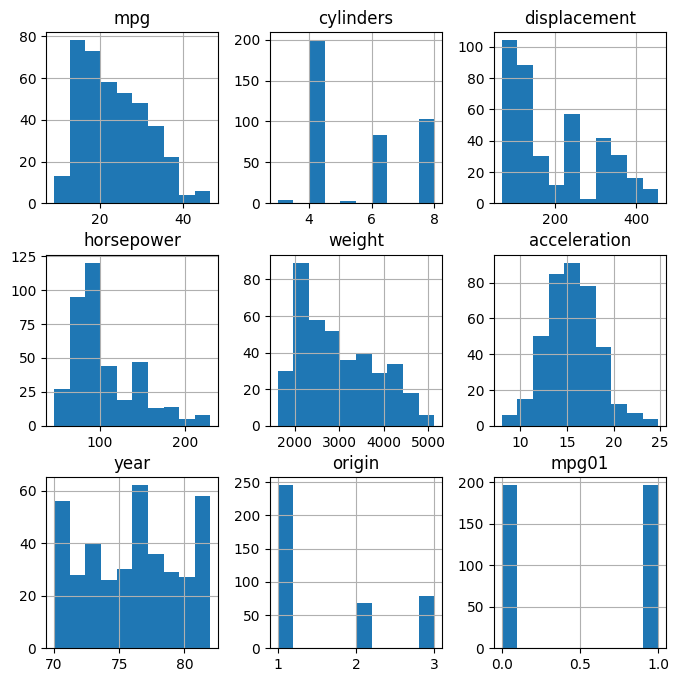

In [24]:
Auto.hist(figsize=(8,8));

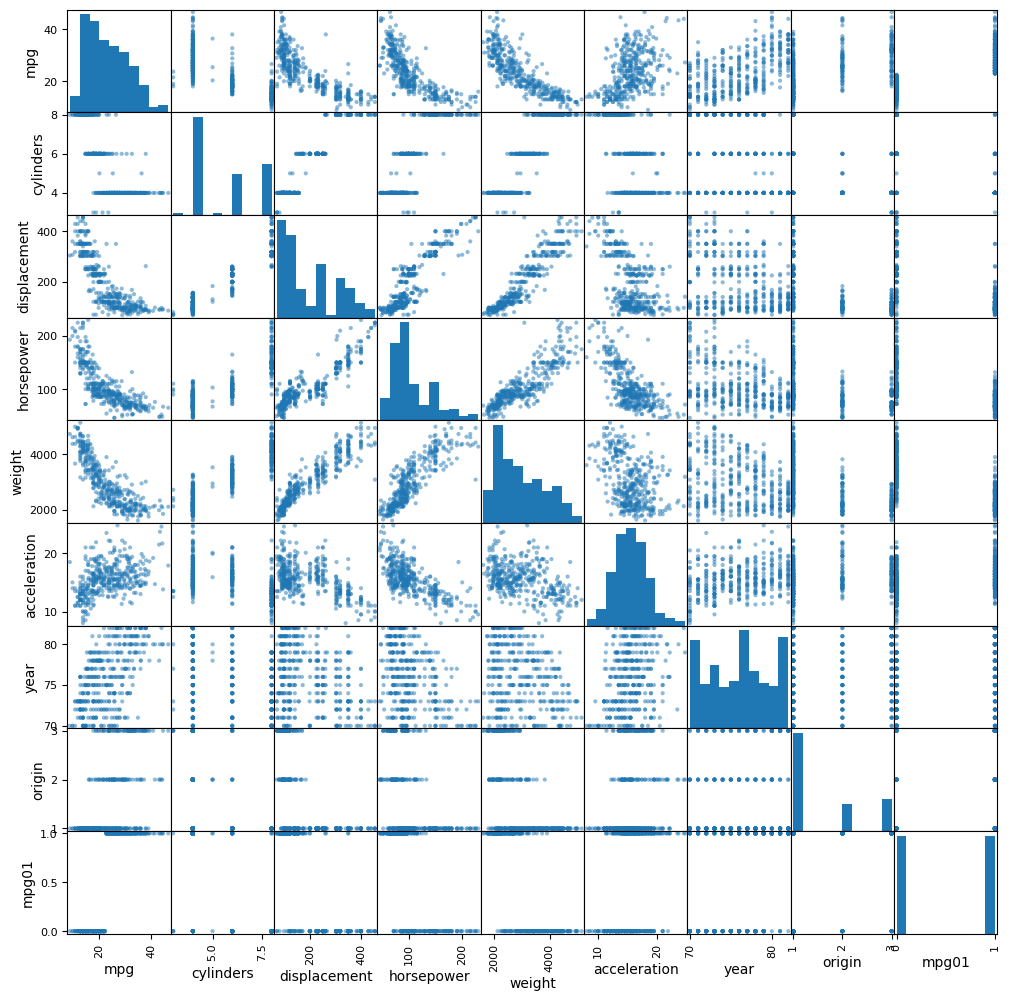

In [25]:
pd.plotting.scatter_matrix(Auto, figsize=(12,12));

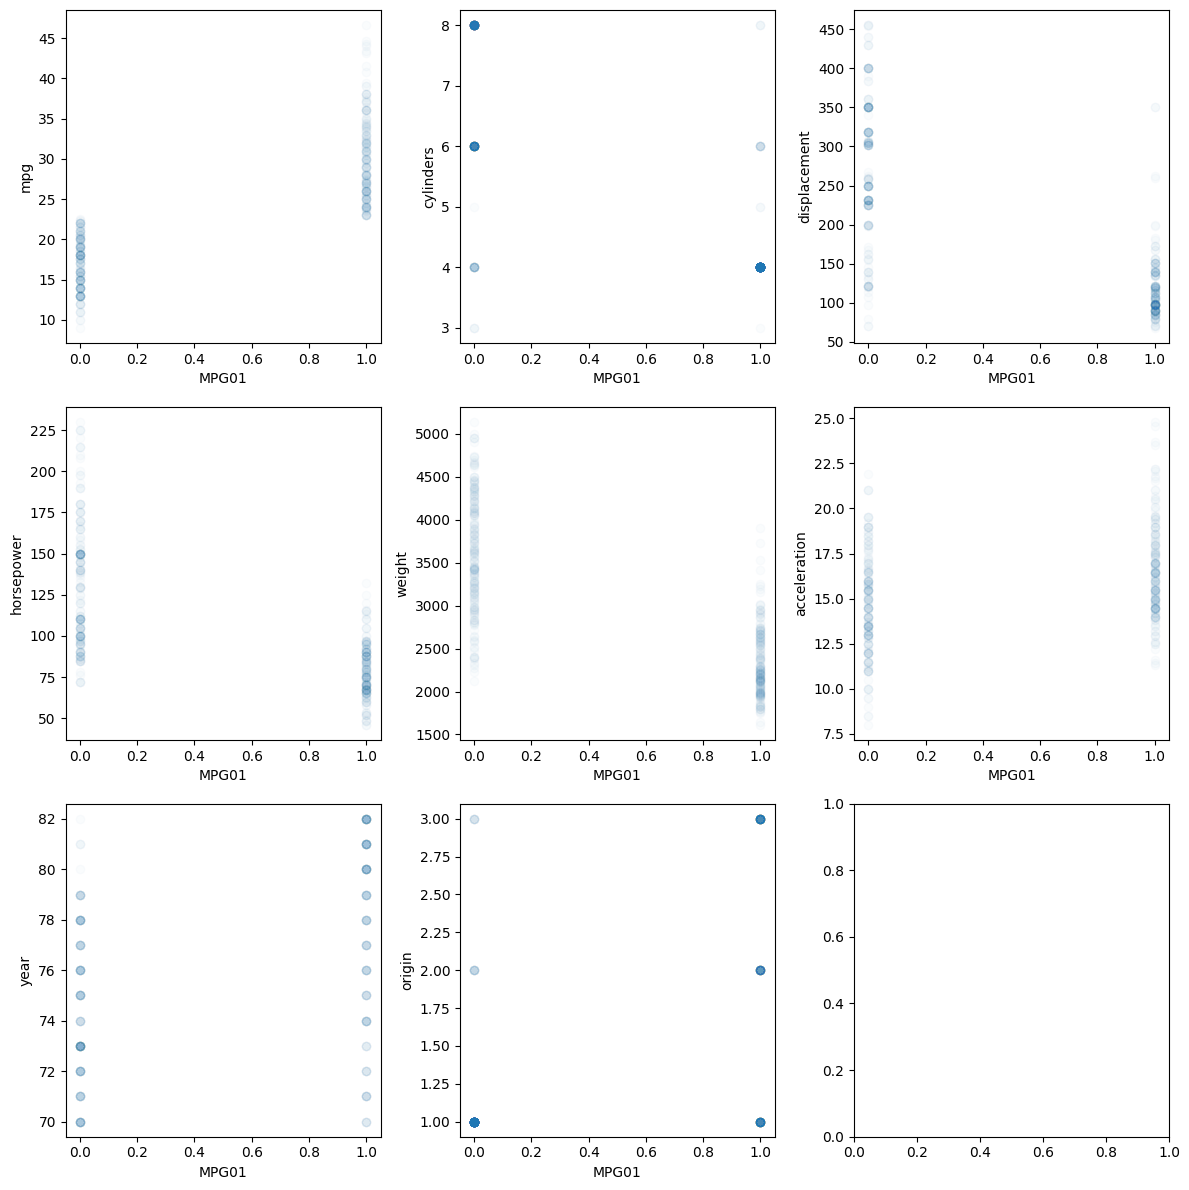

In [26]:
colunas = Auto.columns.drop(['name','mpg01'])
fig,axes = plt.subplots(nrows=3, ncols=3, figsize=(12,12))
axes_flat = axes.flatten()

for coluna, ax in zip(colunas,axes_flat):
    ax.scatter(Auto['mpg01'], Auto[coluna], alpha=0.02)
    ax.set_xlabel('MPG01')
    ax.set_ylabel(coluna)   

plt.tight_layout()
plt.show()

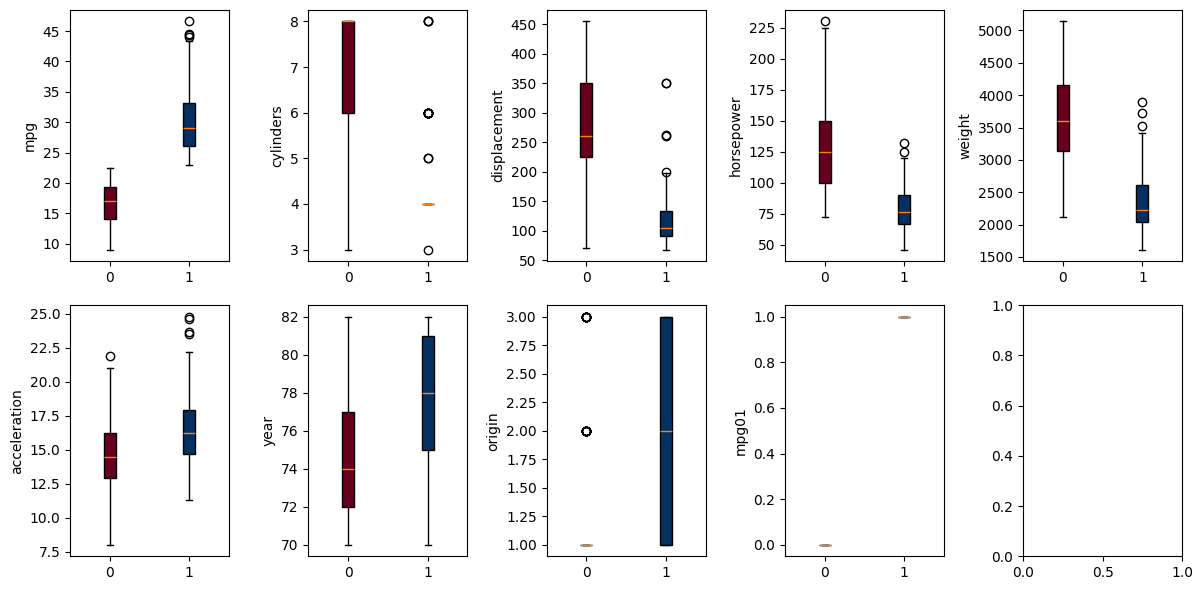

In [27]:
def plotar_boxplot(df, nome_coluna_categorica, figsize, ncolunas=4, cmap_nome='RdBu'):
    colunas = df.select_dtypes(include=[np.number]).columns
    nlinhas = len(colunas)//ncolunas
    if (len(colunas)%ncolunas) > 0:
        nlinhas += 1
    categorias = df[nome_coluna_categorica].unique()
    ncategorias = len(categorias)
    cmap = plt.get_cmap(cmap_nome)
    cores = [cmap(i / max(1, ncategorias - 1)) for i in range(ncategorias)]

    fig, axes = plt.subplots(nrows=nlinhas, ncols=ncolunas, figsize=figsize)
    axes_flat = axes.flatten()
    for coluna, ax in zip(colunas, axes_flat):
        ax.set_ylabel(coluna)
        box = ax.boxplot([df[df[nome_coluna_categorica] == cat][coluna] for cat in categorias], 
                        tick_labels=categorias, 
                        patch_artist=True);
        
        for caixa, cor in zip(box['boxes'], cores):
            caixa.set_facecolor(cor)
    plt.tight_layout()
    plt.show()

plotar_boxplot(Auto, 'mpg01', (12,6), 5)

(c) Split the data into a training set and a test set.

In [127]:
colunas_preditores = ['weight','horsepower','year', 'displacement']
y = Auto['mpg01']
X = MS(colunas_preditores, intercept=False).fit_transform(Auto)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)
X_std.describe()

,weight,horsepower,year,displacement
count,3.920000e+02,3.920000e+02,3.920000e+02,3.920000e+02
mean,-1.812609e-17,-1.812609e-16,-1.160070e-15,-7.250436e-17
std,1.001278e+00,1.001278e+00,1.001278e+00,1.001278e+00
min,-1.608575e+00,-1.520975e+00,-1.625315e+00,-1.209563e+00
25%,-8.868535e-01,-7.665929e-01,-8.098841e-01,-8.555316e-01
50%,-2.052109e-01,-2.853488e-01,5.547151e-03,-4.153842e-01
75%,7.510927e-01,5.600800e-01,8.209784e-01,7.782764e-01
max,2.549061e+00,3.265452e+00,1.636410e+00,2.493416e+00


In [128]:
X_std_treino, X_std_teste, y_treino, y_teste = train_test_split(X_std, y, test_size=.20, random_state=42)

(d) Perform LDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?


In [133]:
lda = LDA(store_covariance=True)
lda.fit(X_std_treino, y_treino)
predicao_lda = lda.predict(X_std_teste)
lda_confusao = confusion_table(predicao_lda, y_teste)
lda_confusao

Truth,0,1
Predicted,,
0,32,0
1,10,37


In [135]:
def metricas_matriz_confusao(matriz_confusao):
    TP = matriz_confusao[1][1]
    TN = matriz_confusao[0][0] 
    FP = matriz_confusao[1][0] 
    FN = matriz_confusao[0][1]
    TP,TN,FP,FN
    acuracia = (TP+TN) / (TP+TN+FP+FN)
    precisao = TP/(TP+FP)
    sensibilidade = TP/(TP+FN)
    especificidade = TN/(TN+FP)
    print(f'Acurácia: {acuracia}\nPrecisão: {precisao}\nSensibilidade: {sensibilidade}\nEspecificidade: {especificidade}')
    return acuracia, precisao, sensibilidade, especificidade

metricas_matriz_confusao(lda_confusao)

Acurácia: 0.8734177215189873
Precisão: 1.0
Sensibilidade: 0.7872340425531915
Especificidade: 1.0


(np.float64(0.8734177215189873),
 np.float64(1.0),
 np.float64(0.7872340425531915),
 np.float64(1.0))

(e) Perform QDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

In [139]:
qda = QDA(store_covariance=True)
qda.fit(X_std_treino, y_treino)
predicao_qda = qda.predict(X_std_teste)
qda_confusao = confusion_table(predicao_qda, y_teste)
metricas_matriz_confusao(qda_confusao)
qda_confusao

Acurácia: 0.8860759493670886
Precisão: 0.972972972972973
Sensibilidade: 0.8181818181818182
Especificidade: 0.9714285714285714


Truth,0,1
Predicted,,
0,34,1
1,8,36


(f) Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [137]:
resultados = sm.GLM(y_treino, X_std_treino, family=sm.families.Binomial()).fit()
predicao = resultados.predict(X_std_teste)
summarize(resultados)

,coef,std err,z,P>|z|
weight,-3.9505,0.863,-4.576,0.000
horsepower,-0.6592,0.528,-1.248,0.212
year,1.7268,0.330,5.238,0.000
displacement,0.1713,0.633,0.271,0.787


In [138]:
LR_confusao = confusion_table((predicao>.5).astype(int), y_teste)
metricas_matriz_confusao(LR_confusao)
LR_confusao

Acurácia: 0.8481012658227848
Precisão: 0.972972972972973
Sensibilidade: 0.7659574468085106
Especificidade: 0.96875


Truth,0,1
Predicted,,
0,31,1
1,11,36


(g) Perform naive Bayes on the training data in order to predict
mpg01 using the variables that seemed most associated with mpg01
in (b). What is the test error of the model obtained?

In [140]:
nb = GaussianNB()
nb.fit(X_std_treino, y_treino)
nb_predicao = nb.predict(X_std_teste)
nb_confusao = confusion_table(nb_predicao, y_teste)
metricas_matriz_confusao(nb_confusao)
nb_confusao

Acurácia: 0.8860759493670886
Precisão: 1.0
Sensibilidade: 0.8043478260869565
Especificidade: 1.0


Truth,0,1
Predicted,,
0,33,0
1,9,37


(h) Perform KNN on the training data, with several values of K, in
order to predict mpg01. Use only the variables that seemed most
associated with mpg01 in (b). What test errors do you obtain?
Which value of K seems to perform the best on this data set?

In [151]:
for i in np.arange(1,18,2):
    print(f'***************Neighbors {i}***************')
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_std_treino, y_treino)
    knn_predicao = knn.predict(X_std_teste)
    knn_confusao = confusion_table(knn_predicao, y_teste)
    metricas_matriz_confusao(knn_confusao)
    print(knn_confusao)

***************Neighbors 1***************
Acurácia: 0.8987341772151899
Precisão: 0.9459459459459459
Sensibilidade: 0.8536585365853658
Especificidade: 0.9473684210526315
Truth       0   1
Predicted        
0          36   2
1           6  35
***************Neighbors 3***************
Acurácia: 0.9367088607594937
Precisão: 0.972972972972973
Sensibilidade: 0.9
Especificidade: 0.9743589743589743
Truth       0   1
Predicted        
0          38   1
1           4  36
***************Neighbors 5***************
Acurácia: 0.8987341772151899
Precisão: 0.918918918918919
Sensibilidade: 0.8717948717948718
Especificidade: 0.925
Truth       0   1
Predicted        
0          37   3
1           5  34
***************Neighbors 7***************
Acurácia: 0.9113924050632911
Precisão: 0.972972972972973
Sensibilidade: 0.8571428571428571
Especificidade: 0.972972972972973
Truth       0   1
Predicted        
0          36   1
1           6  36
***************Neighbors 9***************
Acurácia: 0.89873417721518